<a href="https://colab.research.google.com/github/Kari-2005/carisurg-portfolio/blob/main/notebooks/Week6/Week6_Interim_Baseline_Ansarah_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 6 Interim: Baseline Triage Model

**Student:** Ansarah Mohammed  
**Project:** Caribbean ED Validation of Machine-Learning Triage Support  
**Dataset:** Mercer Emergency Department Triage Dataset  
**Target variable:** ESI triage level  
**Random seed:** 42  

## Interim Objective

The purpose of this notebook is to develop and evaluate baseline machine-learning models for predicting patient triage level. The dataset will be divided into an 80% training set and a 20% testing set using a stratified split. Logistic regression and a decision tree will be compared with a stratified random-guess baseline.

The primary clinical metric is recall for ESI Level 1 because failing to identify a patient who requires immediate life-saving intervention could delay urgent treatment.

In [237]:
# Data handling
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt

# Data preparation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Baseline models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier

# Model evaluation
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    recall_score
)

# Fixed settings used throughout the notebook
RANDOM_STATE = 42
TEST_SIZE = 0.20
ESI_LABELS = [1, 2, 3, 4, 5]

print("Libraries loaded successfully.")
print("Random seed:", RANDOM_STATE)
print("Test-set proportion:", TEST_SIZE)

Libraries loaded successfully.
Random seed: 42
Test-set proportion: 0.2


## Loading the Dataset

The dataset is stored in Google Drive. This section connects the notebook to Google Drive, loads the Week 5 CSV file, and performs an initial check of its structure.

In [238]:
# Importing the Google Drive tool provided by Colab
from google.colab import drive

# Connecting this notebook to Google Drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [239]:
# Storing the location of the Week 5 dataset in a variable
# Keeping the path in one variable to make it easier to update later if needed
DATA_PATH = "/content/drive/MyDrive/CARISURG/Week5/yaleemmlc_admissionprediction_triage.csv"

# Read the CSV file and store it as a pandas DataFrame called df
# A DataFrame is a table of rows and columns that Python can analyse
df = pd.read_csv(DATA_PATH)

# Print a confirmation that the file loaded successfully
print("Dataset loaded successfully.")

# Display the number of patient records and columns
print("Dataset shape:", df.shape)

# Show the first five rows so that we can inspect the dataset
df.head()

Dataset loaded successfully.
Dataset shape: (55121, 226)


,Unnamed: 0,dep_name,esi,age,gender,ethnicity,race,lang,religion,maritalstatus,...,cc_vaginaldischarge,cc_vaginalpain,cc_weakness,cc_wheezing,cc_withdrawal-alcohol,cc_woundcheck,cc_woundinfection,cc_woundre-evaluation,cc_wristinjury,cc_wristpain
0,7,A,4.0,87.0,Female,Hispanic or Latino,Other,Other,Pentecostal,Widowed,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,17,B,2.0,53.0,Male,Hispanic or Latino,Other,English,Catholic,Significant Other,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,40,A,2.0,49.0,Female,Non-Hispanic,White or Caucasian,English,Catholic,Married,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,47,A,3.0,22.0,Female,Hispanic or Latino,White or Caucasian,English,Catholic,Single,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,60,A,2.0,62.0,Male,Non-Hispanic,White or Caucasian,English,Protestant,Divorced,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Select the Target and Predictor Variables

The target variable is `esi`, which represents the patient’s assigned Emergency Severity Index level.

The predictor variables are patient details, vital signs, and chief-complaint indicators available during triage. Post-triage variables such as disposition are excluded because they would not be known when the triage prediction is made and could cause data leakage.

In [240]:
# Identify the column that the models will try to predict
TARGET = "esi"

# Select the clinically relevant information available during triage
# These are the features that were shortlisted during the Week 5
FEATURES = [
    "age",
    "triage_vital_o2_device",
    "triage_vital_o2",
    "cc_chestpain",
    "cc_shortnessofbreath",
    "cc_alteredmentalstatus",
    "triage_glucose",
    "triage_vital_hr",
    "triage_vital_rr",
    "triage_vital_sbp"
]

# Check whether every selected feature and the target exist in the dataset
# This prevents the notebook from continuing with a misspelled or missing column
required_columns = FEATURES + [TARGET]
missing_columns = [
    column for column in required_columns
    if column not in df.columns
]

# Stop the notebook and show a clear error if any columns are missing
if missing_columns:
    raise ValueError(
        f"The following required columns were not found: {missing_columns}"
    )

print("All selected columns were found successfully.")
print("Number of predictor variables:", len(FEATURES))
print("Target variable:", TARGET)

All selected columns were found successfully.
Number of predictor variables: 10
Target variable: esi


In [241]:
# Create a separate DataFrame containing only the selected features
# and the ESI target needed for modelling
model_df = df[FEATURES + [TARGET]].copy()

# Display the size of the modelling dataset
print("Modelling dataset shape:", model_df.shape)

# Show the first five rows of the selected modelling data
model_df.head()

Modelling dataset shape: (55121, 11)


,age,triage_vital_o2_device,triage_vital_o2,cc_chestpain,cc_shortnessofbreath,cc_alteredmentalstatus,triage_glucose,triage_vital_hr,triage_vital_rr,triage_vital_sbp,esi
0,87.0,0.0,98.0,0.0,0.0,0.0,87.0,88.0,17.0,155.0,4.0
1,53.0,0.0,98.0,0.0,0.0,0.0,113.0,118.0,20.0,105.0,2.0
2,49.0,0.0,99.0,0.0,0.0,0.0,108.0,76.0,18.0,116.0,2.0
3,22.0,0.0,97.0,0.0,0.0,0.0,85.0,106.0,16.0,103.0,3.0
4,62.0,0.0,95.0,0.0,0.0,0.0,88.0,84.0,18.0,109.0,2.0


In [242]:
# Count the number of patients assigned to each ESI level
esi_counts = model_df[TARGET].value_counts().sort_index()

# Calculate the percentage of patients in each ESI level
esi_percentages = (
    model_df[TARGET]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

# Combine the counts and percentages into one easy-to-read table
esi_distribution = pd.DataFrame({
    "Patient Count": esi_counts,
    "Percentage (%)": esi_percentages
})

# Label the index clearly
esi_distribution.index.name = "ESI Level"

print("Distribution of the target variable:")
esi_distribution

Distribution of the target variable:


,Patient Count,Percentage (%)
ESI Level,,
1.0,77,0.14
2.0,17924,32.52
3.0,27010,49.00
4.0,8896,16.14
5.0,1214,2.20


## Prepare the Data for Modelling

Before the dataset is divided into training and testing groups, the selected columns are checked for missing values. Missing information could prevent the models from training correctly or affect the reliability of the results.

In [243]:
# Check each selected column to see whether any patient records contain missing values
# This step is useful because machine-learning models usually cannot work directly with blank values
missing_values = model_df.isnull().sum()

# Create a simple table to make the missing-value results easier to read
missing_values_table = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage Missing (%)": (
        missing_values / len(model_df) * 100
    ).round(2)
})

print("Missing values in the modelling dataset:")
missing_values_table

Missing values in the modelling dataset:


,Missing Values,Percentage Missing (%)
age,0,0.0
triage_vital_o2_device,0,0.0
triage_vital_o2,0,0.0
cc_chestpain,0,0.0
cc_shortnessofbreath,0,0.0
cc_alteredmentalstatus,0,0.0
triage_glucose,0,0.0
triage_vital_hr,0,0.0
triage_vital_rr,0,0.0
triage_vital_sbp,0,0.0


### Separate the Predictor Variables and Target Variable

The predictor variables are stored as `X`, while the actual ESI triage level is stored as `y`. The models will use the information in `X` to learn how to predict the correct value in `y`.

In [244]:
# Store the selected patient information and vital signs as X
# These are the clues that will be given to the models
X = model_df[FEATURES].copy()

# Store the actual ESI triage levels as y
# This is the answer that the models will be trained to predict
y = model_df[TARGET].copy()

# Convert the ESI values from decimal numbers such as 1.0 into whole numbers such as 1
# The values represent categories rather than measurements, so whole numbers are more appropriate
y = y.astype(int)

# Display the size of X and y to confirm that the same number of patients is present in both
print("Shape of the predictor data, X:", X.shape)
print("Shape of the target data, y:", y.shape)

# Display the first few target values as a quick check
print("\nFirst five ESI target values:")
print(y.head())

Shape of the predictor data, X: (55121, 10)
Shape of the target data, y: (55121,)

First five ESI target values:
0    4
1    2
2    2
3    3
4    2
Name: esi, dtype: int64


## Create the Training and Testing Sets

The dataset is divided into an 80% training set and a 20% testing set. The training set is used by the models to learn patterns in the patient data, while the testing set is kept separate and used to evaluate how well the models perform on unseen patients.

A stratified split is used so that the proportion of each ESI level remains similar in both groups. A fixed random seed of 42 is also used so that the same patients are placed into each group whenever the notebook is run.

In [245]:
# Divide the patient records into training and testing groups
# Eighty per cent of the data will be used for training, while twenty per cent will be kept for testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,

    # Stratification helps to preserve the original balance of ESI levels in both groups
    stratify=y,

    # The fixed seed ensures that the same split can be reproduced each time
    random_state=RANDOM_STATE
)

# Display the number of patient records placed into each group
print("Number of patients in the training set:", len(X_train))
print("Number of patients in the testing set:", len(X_test))

# Confirm that the predictor and target sections contain matching numbers of patients
print("\nTraining predictor shape:", X_train.shape)
print("Training target shape:", y_train.shape)
print("Testing predictor shape:", X_test.shape)
print("Testing target shape:", y_test.shape)

Number of patients in the training set: 44096
Number of patients in the testing set: 11025

Training predictor shape: (44096, 10)
Training target shape: (44096,)
Testing predictor shape: (11025, 10)
Testing target shape: (11025,)


In [246]:
# Calculate the percentage of each ESI level in the training set
training_distribution = (
    y_train.value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

# Calculate the percentage of each ESI level in the testing set
testing_distribution = (
    y_test.value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

# Place both distributions next to each other so they can be compared easily
split_distribution = pd.DataFrame({
    "Training Set (%)": training_distribution,
    "Testing Set (%)": testing_distribution
})

split_distribution.index.name = "ESI Level"

print("Comparison of ESI distributions after the stratified split:")
split_distribution

Comparison of ESI distributions after the stratified split:


,Training Set (%),Testing Set (%)
ESI Level,,
1,0.14,0.15
2,32.52,32.52
3,49.00,49.00
4,16.14,16.14
5,2.20,2.20


## Create a Stratified Random-Guess Baseline

Before evaluating the machine-learning models, a simple random-guess baseline is created. This model does not learn clinical relationships between patient information and ESI level. Instead, it makes guesses while following approximately the same ESI distribution found in the training data.

The logistic regression and decision tree should perform better than this baseline to show that they have learned useful patterns rather than simply guessing.

In [247]:
# Create a dummy classifier that makes random predictions
# The "stratified" strategy follows approximately the same ESI proportions
# that are present in the training data
dummy_model = DummyClassifier(
    strategy="stratified",
    random_state=RANDOM_STATE
)

# Train the dummy model using the training data
# Although this model does not learn real clinical patterns,
# the fit step allows it to identify the distribution of the ESI classes
dummy_model.fit(X_train, y_train)

# Use the dummy model to make predictions for the unseen testing patients
dummy_predictions = dummy_model.predict(X_test)

# Calculate the proportion of testing patients that were classified correctly
dummy_accuracy = accuracy_score(y_test, dummy_predictions)

print("Stratified random baseline trained successfully.")
print("Dummy baseline accuracy:", round(dummy_accuracy, 3))

Stratified random baseline trained successfully.
Dummy baseline accuracy: 0.375


## Train the Logistic Regression Baseline

Logistic regression is used as the first real baseline model. The predictor variables are measured using different units and ranges. For example, age may be measured in years, oxygen saturation as a percentage, and heart rate in beats per minute.

The variables are therefore scaled before the model is trained. Scaling places them on a more comparable numerical range and helps logistic regression learn more effectively.

In [248]:
# Create the scaler that will place the predictor variables
# onto a more comparable numerical scale
scaler = StandardScaler()

# Learn the scaling values from the training data and apply them
# Only the training data is used to calculate the averages and spreads
# so that information from the testing patients is not used during training
X_train_scaled = scaler.fit_transform(X_train)

# Apply the same scaling values to the testing data
# A new set of averages is not calculated for the test set
X_test_scaled = scaler.transform(X_test)

print("Training and testing features were scaled successfully.")
print("Scaled training shape:", X_train_scaled.shape)
print("Scaled testing shape:", X_test_scaled.shape)

Training and testing features were scaled successfully.
Scaled training shape: (44096, 10)
Scaled testing shape: (11025, 10)


In [249]:
# Create the logistic regression baseline model
# A higher maximum number of iterations is allowed so that the model
# has enough time to settle on a solution without producing a warning
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE
)

# Train the model using the scaled training features
# The model will compare the patient information with the known ESI levels
# and learn patterns that may help separate the five triage categories
logistic_model.fit(X_train_scaled, y_train)

# Use the trained model to predict the ESI levels
# for the patients that were kept in the testing set
logistic_predictions = logistic_model.predict(X_test_scaled)

# Calculate the overall proportion of correct predictions
logistic_accuracy = accuracy_score(y_test, logistic_predictions)

print("Logistic regression model trained successfully.")
print("Logistic regression accuracy:", round(logistic_accuracy, 3))

Logistic regression model trained successfully.
Logistic regression accuracy: 0.545


## Evaluate the Logistic Regression Model

The model is evaluated using accuracy, precision, recall, and F1-score for each ESI level. Looking at each class separately is important because the dataset is imbalanced, and a single overall accuracy value may hide poor performance for rare classes such as ESI Level 1.

In [250]:
# Create a detailed performance report for each ESI level
# Precision shows how often predictions for a class were correct
# Recall shows how many of the real patients in that class were identified
# F1-score gives a balance between precision and recall
logistic_report = classification_report(
    y_test,
    logistic_predictions,
    labels=ESI_LABELS,
    target_names=[
        "ESI Level 1",
        "ESI Level 2",
        "ESI Level 3",
        "ESI Level 4",
        "ESI Level 5"
    ],
    digits=3,

    # A value of zero is shown instead of producing an error
    # if the model does not predict one of the rare ESI classes
    zero_division=0
)

print("Logistic Regression Classification Report:")
print(logistic_report)

Logistic Regression Classification Report:
              precision    recall  f1-score   support

 ESI Level 1      0.000     0.000     0.000        16
 ESI Level 2      0.656     0.341     0.449      3585
 ESI Level 3      0.522     0.885     0.657      5402
 ESI Level 4      0.200     0.001     0.001      1779
 ESI Level 5      0.000     0.000     0.000       243

    accuracy                          0.545     11025
   macro avg      0.276     0.245     0.221     11025
weighted avg      0.502     0.545     0.468     11025



In [251]:
# Generate the same classification report as a dictionary
# This makes it easier to extract individual results and place them into a table
logistic_report_dict = classification_report(
    y_test,
    logistic_predictions,
    labels=ESI_LABELS,
    target_names=[
        "ESI Level 1",
        "ESI Level 2",
        "ESI Level 3",
        "ESI Level 4",
        "ESI Level 5"
    ],
    output_dict=True,
    zero_division=0
)

# Convert the report into a DataFrame so that it is easier to read in the notebook
logistic_metrics_table = pd.DataFrame(logistic_report_dict).transpose()

# Round the values to three decimal places
logistic_metrics_table = logistic_metrics_table.round(3)

print("Detailed logistic regression metrics:")
logistic_metrics_table

Detailed logistic regression metrics:


,precision,recall,f1-score,support
ESI Level 1,0.000,0.000,0.000,16.000
ESI Level 2,0.656,0.341,0.449,3585.000
ESI Level 3,0.522,0.885,0.657,5402.000
ESI Level 4,0.200,0.001,0.001,1779.000
ESI Level 5,0.000,0.000,0.000,243.000
accuracy,0.545,0.545,0.545,0.545
macro avg,0.276,0.245,0.221,11025.000
weighted avg,0.502,0.545,0.468,11025.000


In [252]:
# Extract the recall score for ESI Level 1
# This is the main clinical metric because it measures how many
# truly critical patients were correctly recognised by the model
logistic_esi1_recall = logistic_report_dict["ESI Level 1"]["recall"]

# Extract macro F1
# Macro F1 gives equal importance to every ESI level,
# including the rare classes
logistic_macro_f1 = logistic_report_dict["macro avg"]["f1-score"]

# Extract weighted F1
# Weighted F1 gives more influence to the larger ESI classes,
# such as ESI Levels 2 and 3
logistic_weighted_f1 = logistic_report_dict["weighted avg"]["f1-score"]

# Display the main evaluation results together
print("Logistic Regression Summary")
print("---------------------------")
print("Accuracy:", round(logistic_accuracy, 3))
print("Macro F1:", round(logistic_macro_f1, 3))
print("Weighted F1:", round(logistic_weighted_f1, 3))
print("Recall for ESI Level 1:", round(logistic_esi1_recall, 3))

Logistic Regression Summary
---------------------------
Accuracy: 0.545
Macro F1: 0.221
Weighted F1: 0.468
Recall for ESI Level 1: 0.0


In [253]:
# Calculate the main results for the stratified random baseline
dummy_report_dict = classification_report(
    y_test,
    dummy_predictions,
    labels=ESI_LABELS,
    target_names=[
        "ESI Level 1",
        "ESI Level 2",
        "ESI Level 3",
        "ESI Level 4",
        "ESI Level 5"
    ],
    output_dict=True,
    zero_division=0
)

# Create a small comparison table using the same measurements for both models
baseline_comparison = pd.DataFrame({
    "Model": [
        "Stratified Random Baseline",
        "Logistic Regression"
    ],
    "Accuracy": [
        dummy_accuracy,
        logistic_accuracy
    ],
    "Macro F1": [
        dummy_report_dict["macro avg"]["f1-score"],
        logistic_macro_f1
    ],
    "Weighted F1": [
        dummy_report_dict["weighted avg"]["f1-score"],
        logistic_weighted_f1
    ],
    "Recall for ESI Level 1": [
        dummy_report_dict["ESI Level 1"]["recall"],
        logistic_esi1_recall
    ]
})

# Round the results so that the table is easier to read
baseline_comparison = baseline_comparison.round(3)

print("Comparison with the stratified random baseline:")
baseline_comparison

Comparison with the stratified random baseline:


,Model,Accuracy,Macro F1,Weighted F1,Recall for ESI Level 1
0,Stratified Random Baseline,0.375,0.204,0.375,0.0
1,Logistic Regression,0.545,0.221,0.468,0.0


### Logistic Regression Confusion Matrix

The confusion matrix compares the true ESI level with the level predicted by the model. Values along the main diagonal represent correct predictions, while values outside the diagonal show where patients were assigned to the wrong triage level.

The first row is especially important because it shows how the model classified the true ESI Level 1 patients.

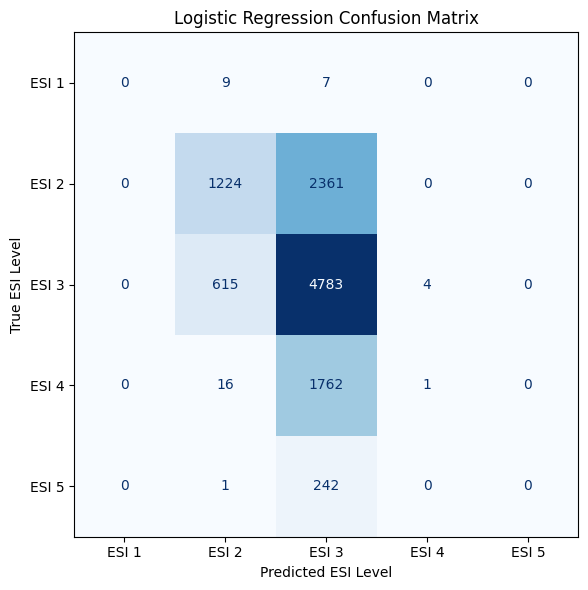

In [254]:
# Create a figure for the logistic regression confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))

# Plot the true ESI levels against the levels predicted by the model
ConfusionMatrixDisplay.from_predictions(
    y_test,
    logistic_predictions,
    labels=ESI_LABELS,
    display_labels=[
        "ESI 1",
        "ESI 2",
        "ESI 3",
        "ESI 4",
        "ESI 5"
    ],
    cmap="Blues",
    colorbar=False,
    ax=ax
)

# Add clear labels and a title so that the figure can be understood
# when it is viewed separately from the notebook
ax.set_title("Logistic Regression Confusion Matrix")
ax.set_xlabel("Predicted ESI Level")
ax.set_ylabel("True ESI Level")

# Adjust the spacing so that no labels are cut off
plt.tight_layout()

# Display the completed figure
plt.show()

### Initial Logistic Regression Interpretation

The logistic regression model achieved an overall accuracy of 54.5%. However, the confusion matrix showed that none of the 16 true ESI Level 1 patients in the testing set were correctly identified. Nine were predicted as ESI Level 2 and seven were predicted as ESI Level 3, resulting in an ESI Level 1 recall of 0.

This shows why overall accuracy is not sufficient for evaluating the model. The model performed better on the more common ESI Levels 2 and 3, but failed to recognise the rarest and most clinically urgent group. In practice, this type of under-triage could delay immediate life-saving care. The result is therefore treated as an important baseline failure rather than evidence that the model is ready for clinical use.

## Train the Decision Tree Baseline

A decision tree was created as the second baseline model. This model works by forming a series of decision rules based on the patient features.

The maximum tree depth was limited to 5. This helps prevent the model from becoming too complex and memorising the training data. A smaller tree is also easier to interpret than an unrestricted tree.

In [255]:
# Create the decision tree baseline model
# The maximum depth is limited to 5 so that the tree does not become overly complex
# and begin memorising patterns that may not apply to new patients
decision_tree_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=RANDOM_STATE
)

# Train the model using the original, unscaled training data
# Decision trees do not require feature scaling
decision_tree_model.fit(X_train, y_train)

# Use the trained tree to predict the ESI levels
# for the patients in the testing set
decision_tree_predictions = decision_tree_model.predict(X_test)

# Calculate the overall proportion of correct predictions
decision_tree_accuracy = accuracy_score(
    y_test,
    decision_tree_predictions
)

print("Decision tree model trained successfully.")
print(
    "Decision tree accuracy:",
    round(decision_tree_accuracy, 3)
)

Decision tree model trained successfully.
Decision tree accuracy: 0.543


In [256]:
# Create a detailed performance report for each ESI level
# This allows the model's performance on the rare and common classes
# to be reviewed separately
decision_tree_report = classification_report(
    y_test,
    decision_tree_predictions,
    labels=ESI_LABELS,
    target_names=[
        "ESI Level 1",
        "ESI Level 2",
        "ESI Level 3",
        "ESI Level 4",
        "ESI Level 5"
    ],
    digits=3,

    # A value of zero is used if the model does not predict
    # one of the rare ESI levels
    zero_division=0
)

print("Decision Tree Classification Report:")
print(decision_tree_report)

Decision Tree Classification Report:
              precision    recall  f1-score   support

 ESI Level 1      0.000     0.000     0.000        16
 ESI Level 2      0.681     0.296     0.413      3585
 ESI Level 3      0.521     0.913     0.663      5402
 ESI Level 4      0.000     0.000     0.000      1779
 ESI Level 5      0.000     0.000     0.000       243

    accuracy                          0.543     11025
   macro avg      0.240     0.242     0.215     11025
weighted avg      0.477     0.543     0.459     11025



In [257]:
# Generate the classification results as a dictionary
# This makes it possible to extract individual scores
# and place them into a comparison table later
decision_tree_report_dict = classification_report(
    y_test,
    decision_tree_predictions,
    labels=ESI_LABELS,
    target_names=[
        "ESI Level 1",
        "ESI Level 2",
        "ESI Level 3",
        "ESI Level 4",
        "ESI Level 5"
    ],
    output_dict=True,
    zero_division=0
)

# Convert the results into a DataFrame for easier viewing
decision_tree_metrics_table = pd.DataFrame(
    decision_tree_report_dict
).transpose()

# Round the values to three decimal places
decision_tree_metrics_table = (
    decision_tree_metrics_table.round(3)
)

print("Detailed decision tree metrics:")
decision_tree_metrics_table

Detailed decision tree metrics:


,precision,recall,f1-score,support
ESI Level 1,0.000,0.000,0.000,16.000
ESI Level 2,0.681,0.296,0.413,3585.000
ESI Level 3,0.521,0.913,0.663,5402.000
ESI Level 4,0.000,0.000,0.000,1779.000
ESI Level 5,0.000,0.000,0.000,243.000
accuracy,0.543,0.543,0.543,0.543
macro avg,0.240,0.242,0.215,11025.000
weighted avg,0.477,0.543,0.459,11025.000


In [258]:
# Extract recall for ESI Level 1
# This remains the primary clinical metric
decision_tree_esi1_recall = (
    decision_tree_report_dict["ESI Level 1"]["recall"]
)

# Extract macro F1, which gives equal importance
# to all five ESI levels
decision_tree_macro_f1 = (
    decision_tree_report_dict["macro avg"]["f1-score"]
)

# Extract weighted F1, which gives more influence
# to the larger ESI groups
decision_tree_weighted_f1 = (
    decision_tree_report_dict["weighted avg"]["f1-score"]
)

# Display the main decision tree results together
print("Decision Tree Summary")
print("---------------------")
print(
    "Accuracy:",
    round(decision_tree_accuracy, 3)
)
print(
    "Macro F1:",
    round(decision_tree_macro_f1, 3)
)
print(
    "Weighted F1:",
    round(decision_tree_weighted_f1, 3)
)
print(
    "Recall for ESI Level 1:",
    round(decision_tree_esi1_recall, 3)
)

Decision Tree Summary
---------------------
Accuracy: 0.543
Macro F1: 0.215
Weighted F1: 0.459
Recall for ESI Level 1: 0.0


### Decision Tree Confusion Matrix

The confusion matrix below shows how the true ESI levels were classified by the decision tree. Correct predictions appear along the main diagonal, while the other cells show where patients were placed into the wrong triage category.

The first row remains the main area of concern because it shows how the true ESI Level 1 patients were classified.

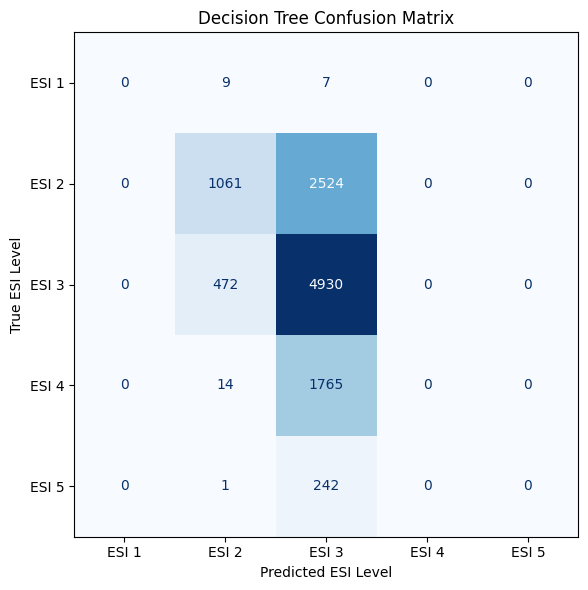

In [259]:
# Create a figure for the decision tree confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))

# Compare the true ESI levels with the levels predicted
# by the decision tree
ConfusionMatrixDisplay.from_predictions(
    y_test,
    decision_tree_predictions,
    labels=ESI_LABELS,
    display_labels=[
        "ESI 1",
        "ESI 2",
        "ESI 3",
        "ESI 4",
        "ESI 5"
    ],
    cmap="Blues",
    colorbar=False,
    ax=ax
)

# Add a clear title and axis labels
ax.set_title("Decision Tree Confusion Matrix")
ax.set_xlabel("Predicted ESI Level")
ax.set_ylabel("True ESI Level")

# Adjust the layout so that all labels remain visible
plt.tight_layout()

# Display the completed confusion matrix
plt.show()

## Compare the Baseline Models

The stratified random baseline, logistic regression, and decision tree are compared using the same testing set. Accuracy, macro F1, weighted F1, and recall for ESI Level 1 are included.

The ESI Level 1 recall remains the primary metric because it shows whether the models can recognise patients requiring immediate life-saving care.

In [260]:
# Create one table containing the main results for all three models
# Using the same metrics makes the comparison fair and easy to interpret
model_comparison = pd.DataFrame({
    "Model": [
        "Stratified Random Baseline",
        "Logistic Regression",
        "Decision Tree"
    ],

    # Accuracy shows the overall percentage of correct predictions
    "Accuracy": [
        dummy_accuracy,
        logistic_accuracy,
        decision_tree_accuracy
    ],

    # Macro F1 gives equal importance to all five ESI levels
    # This is useful because the rare classes should not be ignored
    "Macro F1": [
        dummy_report_dict["macro avg"]["f1-score"],
        logistic_macro_f1,
        decision_tree_macro_f1
    ],

    # Weighted F1 gives more influence to the larger ESI groups
    # This value may appear stronger when performance is better for common classes
    "Weighted F1": [
        dummy_report_dict["weighted avg"]["f1-score"],
        logistic_weighted_f1,
        decision_tree_weighted_f1
    ],

    # ESI Level 1 recall is the main clinical measure used in this notebook
    "Recall for ESI Level 1": [
        dummy_report_dict["ESI Level 1"]["recall"],
        logistic_esi1_recall,
        decision_tree_esi1_recall
    ]
})

# Round the results to three decimal places so that the table is easier to read
model_comparison = model_comparison.round(3)

print("Final baseline model comparison:")
model_comparison

Final baseline model comparison:


,Model,Accuracy,Macro F1,Weighted F1,Recall for ESI Level 1
0,Stratified Random Baseline,0.375,0.204,0.375,0.0
1,Logistic Regression,0.545,0.221,0.468,0.0
2,Decision Tree,0.543,0.215,0.459,0.0


## Interim Findings

Logistic regression produced the highest overall accuracy at 54.5%, while the decision tree achieved 54.3%. Both models performed slightly better on the larger ESI groups, especially ESI Levels 2 and 3. However, neither model correctly identified any of the 16 true ESI Level 1 patients in the testing set.

This resulted in an ESI Level 1 recall of 0 for both models. The finding shows that overall accuracy does not provide a complete picture of performance on an imbalanced triage dataset. A model can correctly classify many common cases while still failing on the rarest and most clinically urgent patients.

The logistic regression model was treated as the stronger initial baseline because it achieved slightly higher accuracy and produced a small number of predictions for ESI Level 4. However, neither model would be suitable for clinical use in its current form. The most concerning failure mode is under-triage of ESI Level 1 patients, since this could delay immediate assessment, resuscitation, or life-saving treatment.

## Save the Interim Outputs

The confusion matrices and comparison table are saved to Google Drive so that they can be added to the Week 6 GitHub folders and shared as part of the interim submission.

In [261]:
# Import the operating-system tool so that folders can be created
import os

# Create a Week 6 output folder inside the CARISURG Google Drive folder
# The folder will be created automatically if it does not already exist
OUTPUT_FOLDER = "/content/drive/MyDrive/CARISURG/Week6"

os.makedirs(OUTPUT_FOLDER, exist_ok=True)

print("Output folder ready:")
print(OUTPUT_FOLDER)

Output folder ready:
/content/drive/MyDrive/CARISURG/Week6


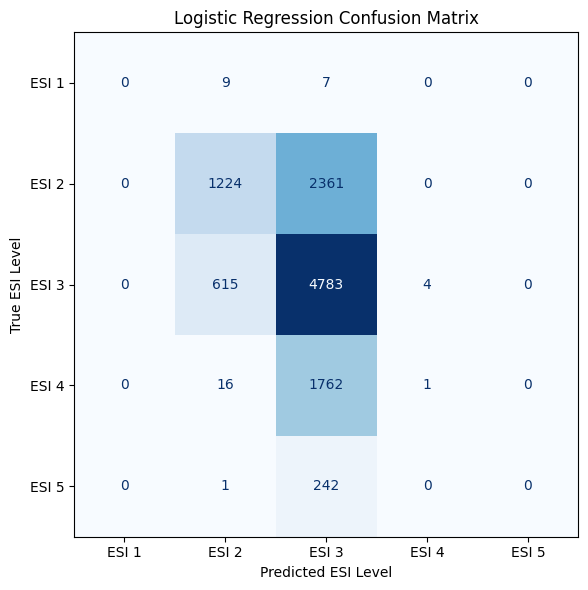

Logistic regression confusion matrix saved to:
/content/drive/MyDrive/CARISURG/Week6/week6_confusion_logistic_regression.png


In [262]:
# Create the logistic regression confusion matrix again
# This version is saved as a high-quality PNG file for GitHub and Discord
fig, ax = plt.subplots(figsize=(8, 6))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    logistic_predictions,
    labels=ESI_LABELS,
    display_labels=[
        "ESI 1",
        "ESI 2",
        "ESI 3",
        "ESI 4",
        "ESI 5"
    ],
    cmap="Blues",
    colorbar=False,
    ax=ax
)

ax.set_title("Logistic Regression Confusion Matrix")
ax.set_xlabel("Predicted ESI Level")
ax.set_ylabel("True ESI Level")

plt.tight_layout()

# Store the full location and filename for the saved figure
logistic_matrix_path = os.path.join(
    OUTPUT_FOLDER,
    "week6_confusion_logistic_regression.png"
)

# Save the image before displaying it
plt.savefig(
    logistic_matrix_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Logistic regression confusion matrix saved to:")
print(logistic_matrix_path)

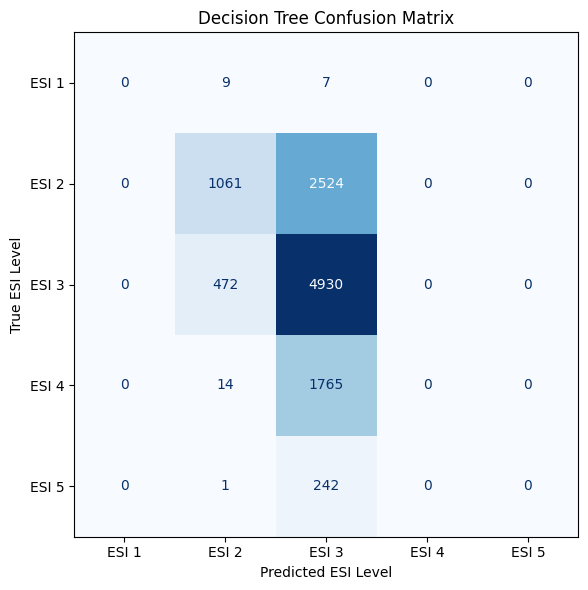

Decision tree confusion matrix saved to:
/content/drive/MyDrive/CARISURG/Week6/week6_confusion_decision_tree.png


In [263]:
# Create and save the decision tree confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    decision_tree_predictions,
    labels=ESI_LABELS,
    display_labels=[
        "ESI 1",
        "ESI 2",
        "ESI 3",
        "ESI 4",
        "ESI 5"
    ],
    cmap="Blues",
    colorbar=False,
    ax=ax
)

ax.set_title("Decision Tree Confusion Matrix")
ax.set_xlabel("Predicted ESI Level")
ax.set_ylabel("True ESI Level")

plt.tight_layout()

# Store the full location and filename for the saved figure
decision_tree_matrix_path = os.path.join(
    OUTPUT_FOLDER,
    "week6_confusion_decision_tree.png"
)

# Save the figure as a high-resolution PNG
plt.savefig(
    decision_tree_matrix_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Decision tree confusion matrix saved to:")
print(decision_tree_matrix_path)

In [264]:
# Save the model comparison table as a CSV file
# This makes the results easy to reuse in the final report
comparison_table_path = os.path.join(
    OUTPUT_FOLDER,
    "week6_baseline_model_comparison.csv"
)

model_comparison.to_csv(
    comparison_table_path,
    index=False
)

print("Model comparison table saved to:")
print(comparison_table_path)

Model comparison table saved to:
/content/drive/MyDrive/CARISURG/Week6/week6_baseline_model_comparison.csv
